# Notebook 05 — Agente Agentic RAG con tool calling

Construir el agente conversacional que consume las 2 colecciones Chroma indexadas y decide cuál usar segun la pregunta. Implementacion basada en (LangGraph + tool calling), **simplificada** para manejar mejor preguntas multi-hop y casos donde el corpus no tiene la respuesta.

## Componentes de este notebook

1. **Baseline RAG clasico** — retrieve→generate fijo, una sola coleccion segun heuristica. Sirve como referencia para la comparativa F8.
2. **Tools `@tool`** — `buscar_mundial` y `buscar_plataforma`. Cada una envuelve la coleccion Chroma correspondiente. Output truncado a 800 chars/chunk + top-k=3 para evitar context overflow.
3. **Agente Agentic ReAct simplificado** — `StateGraph` con 3 nodos: `generate_query_or_respond` → `retrieve` (ToolNode) → `generate_answer`. Sin ciclo grader/rewrite (ver §9).
4. **Visualizacion del grafo** — render Mermaid + fallback ASCII.
5. **Pruebas** — preguntas mixtas (mundial / plataforma / conversacional / multi-hop) con stream de los nodos.

## Decisiones

| Item | Decision | Razon |
|---|---|---|
| Framework | LangGraph | Usado en todo S3 + Taller 3. Patron declarativo con `StateGraph`, observable nodo por nodo. |
| LLM | `gpt-4o-mini` (OpenAI, via `.env`) | Token del curso, RAGAS-friendly, `temperature=0` para reproducibilidad. |
| Embeddings | `text-embedding-3-small` (OpenAI) | Mismo modelo que F5 — obligatorio para que las queries coincidan con el indice. |
| Tools | 2 (`buscar_mundial`, `buscar_plataforma`) | Una por coleccion Chroma F5. El LLM elige segun docstring de cada tool. |
| Tool 3 (DB) | Omitido por ahora | Plan §3.3 lo marca opcional; decidir tras F8. |
| Top-k por tool | 3 | Reducido de 4 para limitar tokens acumulados en agentic flow. |
| Truncado contexto | 800 chars/chunk en tool output | Previene context overflow en gpt-4o-mini (128k). Baseline RAG no trunca (no acumula). |
| Grader + rewrite | **NO usado en el grafo** | El patron `s3_p3` original entraba en loops cuando: (a) multi-tool calls dejaban contexto invisible al grader, (b) la info no existia en corpus. Se reemplazo por un `generate_answer` con prompt explicito de respuesta parcial honesta. Codigo de grader/rewrite queda como referencia documentada. |
| Recursion limit | 4 | Suficiente para flow simplificado (3 pasos max). |

## 1. Setup

In [39]:
from __future__ import annotations

import os
from pathlib import Path
from typing import Literal

import chromadb
from dotenv import load_dotenv
from pydantic import BaseModel, Field

from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, convert_to_messages
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CHROMA_DIR = PROJECT_ROOT / "chroma_db"

load_dotenv(PROJECT_ROOT / ".env")

OPENAI_MODEL = os.getenv("OPENAI_MODEL", "gpt-4o-mini")
EMBEDDING_MODEL = "text-embedding-3-small"

print(f"OpenAI LLM:        {OPENAI_MODEL}")
print(f"OpenAI Embeddings: {EMBEDDING_MODEL}")
print(f"Chroma dir existe: {CHROMA_DIR.exists()}")
assert os.getenv("OPENAI_API_KEY"), "Falta OPENAI_API_KEY en .env"

OpenAI LLM:        gpt-4o-mini
OpenAI Embeddings: text-embedding-3-small
Chroma dir existe: True


## 2. Cargar embeddings OpenAI + colecciones Chroma F5

Reutilizamos el mismo modelo de embeddings que F5 (`text-embedding-3-small`). **Critico:** las queries pasan como `query_embeddings` (precomputadas), no `query_texts` — si dejamos que Chroma calcule embeddings con su default `all-MiniLM-L6-v2`, no coincidirian con los del indice (dim 384 vs 1536).

In [40]:
embedder = OpenAIEmbeddings(
    model=EMBEDDING_MODEL,
    api_key=os.getenv("OPENAI_API_KEY"),
)

# Test conexion + dim
_test = embedder.embed_query("hola")
print(f"Embeddings OK — dim={len(_test)} (esperado 1536)")


def embed_query(text):
    # Un embedding para query unica.
    return embedder.embed_query(text)


client = chromadb.PersistentClient(path=str(CHROMA_DIR))
col_mundial = client.get_collection("mundial")
col_plataforma = client.get_collection("plataforma")
print(f"\nColeccion mundial:    {col_mundial.count()} chunks")
print(f"Coleccion plataforma: {col_plataforma.count()} chunks")

Embeddings OK — dim=1536 (esperado 1536)

Coleccion mundial:    4497 chunks
Coleccion plataforma: 316 chunks


## 3. LLM

`temperature=0` para que las decisiones del agente (cual tool llamar, grading binario, rewrite) sean reproducibles.

In [41]:
llm = ChatOpenAI(
    model=OPENAI_MODEL,
    api_key=os.getenv("OPENAI_API_KEY"),
    temperature=0,
)
# Test rapido de conexion
print(llm.invoke("Di hola en una palabra").content)

¡Hola!


## 4. Baseline RAG clasico (sin agente)

Pipeline de un solo paso: dada una pregunta, recupera top-k chunks de **una** coleccion fija + genera respuesta. Sirve como punto de comparacion para F8.

Heuristica primitiva para elegir coleccion: keyword match. En F8 vamos a contrastar esto contra el agente que decide via tool calling.

In [42]:
def retrieve_from(collection, query, k=4):
    # Recupera top-k chunks de una coleccion Chroma.
    q_emb = embed_query(query)
    res = collection.query(
        query_embeddings=[q_emb],
        n_results=k,
        include=["documents", "metadatas", "distances"],
    )
    out = []
    for doc, meta, dist in zip(res["documents"][0], res["metadatas"][0], res["distances"][0]):
        out.append({"content": doc, "metadata": meta, "score": 1 - dist})
    return out


def format_context(chunks, max_chars_per_chunk=None):
    # Formatea chunks como contexto para el LLM.
    # max_chars_per_chunk: si se indica, trunca cada chunk a ese tamaño + "..." sufijo.
    # Esto evita context overflow en los loops del agente (las tools lo usan).
    # Para el baseline pasamos None y mandamos chunks completos.
    parts = []
    for c in chunks:
        src = c["metadata"].get("titulo", c["metadata"].get("ruta", "?"))
        body = c["content"]
        if max_chars_per_chunk and len(body) > max_chars_per_chunk:
            body = body[:max_chars_per_chunk].rstrip() + " [...]"
        parts.append(f"[{src}]\n{body}")
    return "\n\n".join(parts)


BASELINE_PROMPT = (
    "Eres un asistente de preguntas y respuestas en español sobre el Mundial 2026 y la plataforma 91 de predicciones. "
    "Responde SOLO con la informacion del contexto. Si no esta, di 'no lo se' — no inventes. "
    "Cita la fuente entre corchetes cuando uses informacion concreta.\n\n"
    "Pregunta: {question}\n\n"
    "Contexto:\n{context}"
)


PLATAFORMA_KEYWORDS = {
    "tribu", "tribus", "prediccion", "predicciones", "predecir", "ranking",
    "torneo", "torneos", "moneda", "monedas", "tienda", "referido", "referidos",
    "91", "noventayuno", "plataforma", "perfil", "registro", "cuenta",
}


def pick_collection(question):
    # Heuristica de routing del baseline: keyword match. Primitiva a proposito.
    q_lower = question.lower()
    if any(kw in q_lower for kw in PLATAFORMA_KEYWORDS):
        return col_plataforma, "plataforma"
    return col_mundial, "mundial"


def rag_clasico(question, k=4):
    # Pipeline RAG clasico: routing fijo + retrieve + generate. Sin truncar.
    col, col_name = pick_collection(question)
    chunks = retrieve_from(col, question, k=k)
    context = format_context(chunks)
    prompt = BASELINE_PROMPT.format(question=question, context=context)
    answer = llm.invoke([{"role": "user", "content": prompt}]).content
    return {"answer": answer, "collection": col_name, "chunks": chunks}


# Prueba con 2 queries
for q in [
    "¿Cuantos equipos participan en el Mundial 2026?",
    "¿Hasta cuando puedo editar mi prediccion en la plataforma?",
]:
    print(f"\nQ: {q}")
    r = rag_clasico(q)
    print(f"Routed to: {r['collection']}")
    print(f"Answer: {r['answer']}")


Q: ¿Cuantos equipos participan en el Mundial 2026?
Routed to: mundial
Answer: En el Mundial 2026 participarán un total de 48 selecciones [Clasificación para la Copa Mundial de Fútbol de 2026].

Q: ¿Hasta cuando puedo editar mi prediccion en la plataforma?
Routed to: plataforma
Answer: Puedes editar tu predicción hasta antes del inicio del partido. Una vez iniciado el partido, la predicción se bloquea automáticamente y ya no se puede modificar [Cómo predecir partidos en 91].


## 5. Tools del agente

Dos tools con `@tool`. La docstring es lo que el LLM lee para decidir cuando invocarla. Es importante que cada docstring describa con precision el dominio y los tipos de preguntas que aplica.

In [43]:
# Fix context-overflow: truncar cada chunk a 800 chars en el output del tool.
# Esto reduce el tamaño del mensaje tool_result que se acumula en el state del agente.
# F6-v2: TOP_K_TOOL subido de 3 a 5 — el doc partido-104-final (chico, ~30 lineas)
# no rankeaba en top-3 contra chunks Wikipedia largos sobre 'estadios sede'.
TOP_K_TOOL = 5
TOOL_MAX_CHARS_PER_CHUNK = 800


@tool
def buscar_mundial(query: str) -> str:
    """Busca informacion sobre el Mundial de Futbol 2026, ediciones historicas del Mundial,
    selecciones nacionales, jugadores, estadios, reglamento oficial de la FIFA, reglas del futbol,
    estadisticas y resultados historicos. Tambien cubre el CALENDARIO COMPLETO del Mundial 2026:
    los 104 partidos numerados 1-104, cada uno con fecha, hora, estadio, ciudad, fase
    (Fase de Grupos / Octavos / Cuartos / Semifinales / Tercer Puesto / FINAL = partido 104) y equipos.
    Fuentes: Wikipedia ES, Reglamento FIFA 2026 (PDF oficial), Kaggle (1930-2022) y calendario FIFA 2026.
    Usa esta tool cuando la pregunta sea sobre futbol, mundiales, FIFA, partidos especificos
    (incluyendo final, semifinales, partidos de una seleccion), jugadores, selecciones, estadios,
    fechas, horarios o reglas del juego.
    """
    chunks = retrieve_from(col_mundial, query, k=TOP_K_TOOL)
    if not chunks:
        return "Sin resultados."
    return format_context(chunks, max_chars_per_chunk=TOOL_MAX_CHARS_PER_CHUNK)


@tool
def buscar_plataforma(query: str) -> str:
    """Busca informacion sobre la plataforma 91 (noventayuno.com), una plataforma web donde los
    usuarios hacen predicciones del Mundial 2026. Cubre: como predecir partidos, sistema de puntaje,
    rankings (global, tribus, torneos), tribus (crear, unirse, owner, premios y penitencias),
    torneos (individuales, tribus, referidos), monedas internas, tienda, perfil del usuario,
    sistema de referidos, terminos y condiciones, politica de privacidad.
    Usa esta tool cuando la pregunta sea sobre como funciona la plataforma, sus features,
    o como hacer alguna accion en 91.
    """
    chunks = retrieve_from(col_plataforma, query, k=TOP_K_TOOL)
    if not chunks:
        return "Sin resultados."
    return format_context(chunks, max_chars_per_chunk=TOOL_MAX_CHARS_PER_CHUNK)


# Probar las tools directamente
print("=== TEST buscar_mundial ===")
print(buscar_mundial.invoke({"query": "campeon Mundial 2022"})[:600])
print("\n=== TEST buscar_plataforma ===")
print(buscar_plataforma.invoke({"query": "como crear una tribu"})[:600])


=== TEST buscar_mundial ===
[Copa Mundial de Fútbol de 2022]
# Copa Mundial de Fútbol de 2022

La Copa Mundial de Fútbol de 2022 se disputó en Catar. Argentina se coronó campeón al vencer a Francia en la final. Croacia terminó en tercer lugar y Marruecos en cuarto puesto.

[Copa Mundial de Fútbol de 2022]
# Copa Mundial de Fútbol de 2022La Copa Mundial de la FIFA Catar 2022​ (en árabe: كأس العالم لكرة القدم قطر 2022‎) fue la vigésima segunda edición de la Copa Mundial de Fútbol masculino organizada por la FIFA. Esta edición del evento se desarrolló del 20 de noviembre al 18 de diciembre en el otoño de Catar, que consigui

=== TEST buscar_plataforma ===
[Cómo crear una tribu]
# Cómo crear una tribu

Desde la sección "Mi Tribu" en la página de ranking, el usuario puede crear una tribu propia.

URL: https://www.noventayuno.com/ranking → sección "Mi Tribu"

[Cómo crear una tribu]
## Qué debe definir al crear la tribu

Al crear una tribu, el usuario debe definir:

- **Nombre de la tribu** —

## 6. Nodo `generate_query_or_respond`

Primer nodo del grafo. Recibe el historial de mensajes y decide:

- Si la pregunta requiere conocimiento de algun corpus → emite un `tool_call` a la tool apropiada.
- Si es conversacional (ej. *hola*) → responde directo y termina.

`bind_tools([buscar_mundial, buscar_plataforma])` expone las dos firmas al LLM.

In [44]:
TOOLS = [buscar_mundial, buscar_plataforma]
response_model = llm


def generate_query_or_respond(state: MessagesState):
    """Llama al LLM con las tools enlazadas. El LLM decide: recuperar (tool_call) o responder directo."""
    response = response_model.bind_tools(TOOLS).invoke(state["messages"])
    return {"messages": [response]}


# Test 1: conversacional → no debe usar tool
out_conv = generate_query_or_respond({"messages": [{"role": "user", "content": "Hola, como estas?"}]})
print("=== Conversacional ===")
out_conv["messages"][-1].pretty_print()

# Test 2: requiere mundial
out_m = generate_query_or_respond({"messages": [{"role": "user", "content": "¿Quien gano el Mundial 2022?"}]})
print("\n=== Mundial ===")
out_m["messages"][-1].pretty_print()

# Test 3: requiere plataforma
out_p = generate_query_or_respond({"messages": [{"role": "user", "content": "¿Como hago para crear una tribu?"}]})
print("\n=== Plataforma ===")
out_p["messages"][-1].pretty_print()

=== Conversacional ===
================================== Ai Message ==================================

¡Hola! Estoy aquí y listo para ayudarte. ¿En qué puedo asistirte hoy?

=== Mundial ===
================================== Ai Message ==================================
Tool Calls:
  buscar_mundial (call_qsL7msAOhXklXeytAex6w1H6)
 Call ID: call_qsL7msAOhXklXeytAex6w1H6
  Args:
    query: ganador Mundial 2022

=== Plataforma ===
================================== Ai Message ==================================
Tool Calls:
  buscar_plataforma (call_M73JWhg0Q9R29YQhF37d4FNJ)
 Call ID: call_M73JWhg0Q9R29YQhF37d4FNJ
  Args:
    query: crear una tribu


## 7. Nodo `grade_documents` — juzgar relevancia del contexto

Un retriever puede devolver chunks con buena similitud coseno pero que no responden la pregunta. Antes de generar la respuesta, un LLM-juez decide en binario si el contexto es util.

- **yes** → ir a `generate_answer`.
- **no** → ir a `rewrite_question` y reintentar.

`with_structured_output(GradeDocuments)` fuerza salida tipada (no texto libre).

In [45]:
# Fix: grader permisivo. La version estricta inicial mandaba a rewrite_question
# muchos contextos relevantes (ej: chunks sobre estadios 2026 cuando se pregunta por la
# final), provocando loops largos y context overflow. Ahora aceptamos "yes" tambien
# cuando el contexto da informacion parcial o tangencial.
GRADE_PROMPT = (
    "Eres un evaluador de relevancia de documentos para preguntas de un asistente RAG.\n\n"
    "Documento recuperado:\n{context}\n\n"
    "Pregunta del usuario: {question}\n\n"
    "Califica 'yes' si el documento contiene CUALQUIER informacion util — literal, parcial, "
    "tangencial o relacionada semanticamente — que ayude a responder la pregunta o a dar contexto. "
    "Solo califica 'no' cuando el documento sea claramente irrelevante (otro tema, idioma "
    "incorrecto, ruido). Ante la duda, responde 'yes'.\n\n"
    "Responde unicamente con 'yes' o 'no'."
)


class GradeDocuments(BaseModel):
    """Calificacion binaria de relevancia."""
    binary_score: str = Field(description="'yes' si es relevante, 'no' si no lo es")


grader_model = llm


def grade_documents(state: MessagesState) -> Literal["generate_answer", "rewrite_question"]:
    """Edge condicional: decide a donde enrutar tras retrieve."""
    question = state["messages"][0].content
    context = state["messages"][-1].content  # ToolMessage con los chunks

    prompt = GRADE_PROMPT.format(question=question, context=context)
    response = grader_model.with_structured_output(GradeDocuments).invoke(
        [{"role": "user", "content": prompt}]
    )
    if response.binary_score.lower() == "yes":
        return "generate_answer"
    return "rewrite_question"


# Test: contexto irrelevante → debe devolver 'rewrite_question'
test_irrelevante = {
    "messages": convert_to_messages([
        {"role": "user", "content": "¿Quien gano el Mundial 2022?"},
        {"role": "assistant", "content": "", "tool_calls": [
            {"id": "1", "name": "buscar_mundial", "args": {"query": "Mundial 2022"}}
        ]},
        {"role": "tool", "content": "receta de empanadas argentinas", "tool_call_id": "1"},
    ])
}
print("Contexto irrelevante (receta) →", grade_documents(test_irrelevante))

# Test: contexto relevante parcial → debe devolver 'generate_answer'
test_parcial = {
    "messages": convert_to_messages([
        {"role": "user", "content": "¿Quien gano el Mundial 2022?"},
        {"role": "assistant", "content": "", "tool_calls": [
            {"id": "1", "name": "buscar_mundial", "args": {"query": "Mundial 2022"}}
        ]},
        {"role": "tool", "content": "[Copa Mundial 2022] La Copa Mundial 2022 se disputo en Catar. Argentina vencio a Francia en la final.", "tool_call_id": "1"},
    ])
}
print("Contexto relevante (Catar Argentina) →", grade_documents(test_parcial))

Contexto irrelevante (receta) → rewrite_question
Contexto relevante (Catar Argentina) → generate_answer


## 8. Nodo `generate_answer`\n\nGenera la respuesta final con los chunks recuperados. Prompt diseñado para manejar **multi-hop con respuesta parcial**: si parte de la pregunta tiene respuesta en el contexto y parte no, el LLM debe responder lo que sí sabe Y decir explícitamente \"no sé\" para lo que falta. No inventa.\n\n**Nota:** Los nodos `grade_documents` y `rewrite_question` quedaron definidos arriba (cell 14, 16) pero **fuera del grafo principal**. Decisión arquitectónica documentada en cell-18.

In [46]:
REWRITE_PROMPT = (
    "Mira la pregunta original e intenta razonar sobre la intencion semantica subyacente.\n"
    "Pregunta original:\n-------\n{question}\n-------\n"
    "Formula una version mejorada de la pregunta, en español, conservando la intencion. "
    "Se especifico con nombres de selecciones, jugadores, ediciones del Mundial, articulos del reglamento, "
    "o features de la plataforma 91 si los hay."
)


def rewrite_question(state):
    # NO USADO en el grafo actual. Se conserva como referencia del patron s3_p3.
    question = state["messages"][0].content
    prompt = REWRITE_PROMPT.format(question=question)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [HumanMessage(content=response.content)]}


# Prompt para generate_answer: maneja multi-hop con respuesta parcial honesta.
GENERATE_PROMPT = (
    "Eres un asistente de preguntas y respuestas en español sobre el Mundial 2026 y la plataforma 91 de predicciones.\n\n"
    "REGLAS:\n"
    "1. Usa UNICAMENTE la informacion del contexto. NO inventes datos ni infieras lo que no esta escrito.\n"
    "2. Si la pregunta tiene varias partes (multi-hop) y solo encuentras informacion para algunas, responde lo que SI sabes "
    "Y declara explicitamente 'No tengo informacion sobre [parte que falta]' para el resto.\n"
    "3. Si el contexto no contiene NADA util para la pregunta, responde 'No tengo informacion sobre esto en mi base de conocimiento.'\n"
    "4. Cita la fuente entre corchetes [titulo] cuando uses informacion concreta.\n"
    "5. Se conciso (maximo 4-5 oraciones).\n"
    "6. Responde siempre en español.\n\n"
    "Pregunta: {question}\n\n"
    "Contexto recuperado:\n{context}"
)


def generate_answer(state):
    # Genera respuesta final con TODOS los ToolMessages recientes concatenados como contexto.
    # Esto soporta multi-hop: si el LLM llamo a varias tools en paralelo (ej: buscar_mundial +
    # buscar_plataforma), juntamos ambos resultados antes de razonar.
    messages = state["messages"]
    question = messages[0].content

    # Recolectar contexto: todos los ToolMessages consecutivos al final.
    contexts = []
    for msg in reversed(messages):
        # ToolMessage tiene .content y type "tool"
        if hasattr(msg, "type") and msg.type == "tool":
            contexts.append(msg.content)
        else:
            if contexts:
                break  # ya pasamos el bloque de tools, salimos
    contexts.reverse()
    context = "\n\n---\n\n".join(contexts) if contexts else "(sin contexto recuperado)"

    prompt = GENERATE_PROMPT.format(question=question, context=context)
    response = response_model.invoke([{"role": "user", "content": prompt}])
    return {"messages": [response]}

## 9. Ensamblar el grafo

Topologia **simplificada** (vs. patron `s3_p3` que incluye grader+rewrite):

```
START → generate_query_or_respond
          ├── (sin tool_calls) → END
          └── (tool_calls)     → retrieve (ToolNode) → generate_answer → END
```

**Decisión arquitectónica:** se descarta el ciclo `grade_documents` → `rewrite_question` → `generate_query_or_respond` porque:

1. **Multi-tool calls** (ej: `buscar_mundial` + `buscar_plataforma` en paralelo) generan multiples `ToolMessage` en el state. El grader original solo miraba el ultimo → ignoraba parte del contexto.
2. **Preguntas con info parcial en corpus** (ej: "¿en qué estadio juega Argentina su primer partido?" cuando el calendario no esta indexado) hacian loop infinito hasta `recursion_limit`, sin nunca llegar a una respuesta.
3. La pregunta del usuario raramente mejora con rewrite cuando la info simplemente no esta — solo gasta tokens.

**Solucion adoptada:** dejar que `generate_answer` (con prompt explicito de respuesta parcial honesta) maneje todo el contexto disponible, incluyendo el caso "no se" por partes. Mas simple, mas estable, mas predecible.

`grade_documents` y `rewrite_question` quedan definidos como funciones por si se quieren reactivar en una variante futura, pero **no estan en el grafo compilado**.

`tools_condition` es un helper de LangGraph que enruta a `"tools"` si el ultimo mensaje tiene `tool_calls`, o a `END` si no.

In [47]:
workflow = StateGraph(MessagesState)

# Nodos del grafo simplificado: solo 3 (no rewrite, no grade como nodo).
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode(TOOLS))
workflow.add_node("generate_answer", generate_answer)

# Aristas
workflow.add_edge(START, "generate_query_or_respond")

# Si el LLM emitio tool_calls -> retrieve. Si no -> END (conversacional).
workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {"tools": "retrieve", END: END},
)

# Tras retrieve, SIEMPRE generate_answer. Sin ciclos.
workflow.add_edge("retrieve", "generate_answer")
workflow.add_edge("generate_answer", END)

graph = workflow.compile()
print("Grafo compilado (topologia simplificada: sin grader+rewrite).")

Grafo compilado (topologia simplificada: sin grader+rewrite).


## 10. Visualizar el grafo

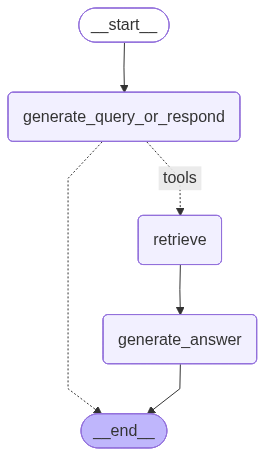

In [48]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print("No se pudo renderizar PNG (requiere conexion a mermaid.ink). Fallback ASCII:")
    print(e)
    print("\n" + graph.get_graph().draw_ascii())

## 11. Probar el agente — preguntas mixtas

Usamos `graph.stream(...)` para ver el paso a paso del agente: que nodo se ejecuto, que decidio, que respondio. Esto es lo que mas claridad da en defensa del proyecto.

In [49]:
# Recursion limit 4: maximo flow es generate_query_or_respond -> retrieve -> generate_answer (3 pasos).
# Con margen 1 para casos conversacionales que terminan en generate (1 paso solo).
RECURSION_LIMIT = 4


def correr_agente(pregunta):
    print("=" * 70)
    print(f"PREGUNTA: {pregunta}")
    print("=" * 70)
    config = {"recursion_limit": RECURSION_LIMIT}
    for chunk in graph.stream({"messages": [{"role": "user", "content": pregunta}]}, config=config):
        for node, update in chunk.items():
            print(f"\n--- Nodo: {node} ---")
            update["messages"][-1].pretty_print()
    print()


# 1) Conversacional -> no debe llamar tool
correr_agente("Hola, ¿que puedes hacer?")

PREGUNTA: Hola, ¿que puedes hacer?

--- Nodo: generate_query_or_respond ---
================================== Ai Message ==================================

¡Hola! Puedo ayudarte con información sobre el Mundial de Fútbol 2026, incluyendo detalles sobre partidos, selecciones, jugadores, estadios y reglas del juego. También puedo proporcionarte información sobre la plataforma 91, donde los usuarios pueden hacer predicciones sobre el Mundial. Si tienes alguna pregunta específica, no dudes en decírmelo.



In [50]:
# 2) Mundial — factual sobre el corpus Wikipedia
correr_agente("¿En que estadio se jugara la final del Mundial 2026?")

PREGUNTA: ¿En que estadio se jugara la final del Mundial 2026?

--- Nodo: generate_query_or_respond ---
================================== Ai Message ==================================
Tool Calls:
  buscar_mundial (call_xFP0qKmjiR5C18niqzV82cCd)
 Call ID: call_xFP0qKmjiR5C18niqzV82cCd
  Args:
    query: final Mundial 2026 estadio

--- Nodo: retrieve ---
================================= Tool Message =================================
Name: buscar_mundial

[Estadio BBVA]
o con el arquitecto Federico Velasco,​​​ V&FO Arquitectos,​​ que ha trabajado en los diseños desde 2008.​ El estadio fue elegido para ser uno de los estadios sede de la Copa Mundial de Fútbol 2026.​​​Características
Tiene capacidad para 53 500 espectadores, después de un incremento a su aforo inicial de 51 000.​
324 Suites.
Cuenta con 2 restaurantes.
Zona comercial.
Tienda oficial del club.
Cancha de entrenamiento anexa.
Estacionamiento con una capacidad para 3 500 coches con un sistema de control de invasiones.
Tiene un

In [51]:
# 3) Mundial — historico desde Kaggle
correr_agente("¿Quien fue campeon del Mundial 2022 y a quien le gano en la final?")

PREGUNTA: ¿Quien fue campeon del Mundial 2022 y a quien le gano en la final?

--- Nodo: generate_query_or_respond ---
================================== Ai Message ==================================
Tool Calls:
  buscar_mundial (call_klDzKS15oeI51UP1nEq31YHk)
 Call ID: call_klDzKS15oeI51UP1nEq31YHk
  Args:
    query: campeon Mundial 2022

--- Nodo: retrieve ---
================================= Tool Message =================================
Name: buscar_mundial

[Copa Mundial de Fútbol de 2022]
# Copa Mundial de Fútbol de 2022

La Copa Mundial de Fútbol de 2022 se disputó en Catar. Argentina se coronó campeón al vencer a Francia en la final. Croacia terminó en tercer lugar y Marruecos en cuarto puesto.

[Copa Mundial de Fútbol de 2022]
# Copa Mundial de Fútbol de 2022La Copa Mundial de la FIFA Catar 2022​ (en árabe: كأس العالم لكرة القدم قطر 2022‎) fue la vigésima segunda edición de la Copa Mundial de Fútbol masculino organizada por la FIFA. Esta edición del evento se desarrolló del 20

In [52]:
# 4) Reglamento FIFA
correr_agente("¿Cuantos equipos participan en el Mundial 2026 segun la FIFA?")

PREGUNTA: ¿Cuantos equipos participan en el Mundial 2026 segun la FIFA?

--- Nodo: generate_query_or_respond ---
================================== Ai Message ==================================
Tool Calls:
  buscar_mundial (call_Ug5ben21pdYFJ12KVyiuQewU)
 Call ID: call_Ug5ben21pdYFJ12KVyiuQewU
  Args:
    query: equipos participantes Mundial 2026

--- Nodo: retrieve ---
================================= Tool Message =================================
Name: buscar_mundial

[Clasificación para la Copa Mundial de Fútbol de 2026]
# Clasificación para la Copa Mundial de Fútbol de 2026

Para la Copa Mundial de Fútbol de 2026, un total de 48 selecciones participarán en la fase final. El 14 de febrero de 2023, el Consejo de la FIFA confirmó que los tres países anfitriones —Canadá, Estados Unidos y México— obtendrían la clasificación automática, pese a que la sede había sido adjudicada desde 2018.​
El resto de las selecciones debió acceder mediante los torneos clasificatorios de cada confederaci

In [53]:
# 5) Plataforma 91
correr_agente("¿Hasta cuando puedo editar mi prediccion antes de un partido?")

PREGUNTA: ¿Hasta cuando puedo editar mi prediccion antes de un partido?

--- Nodo: generate_query_or_respond ---
================================== Ai Message ==================================
Tool Calls:
  buscar_plataforma (call_OYErcwF0V1ppLFcnOOHejx0V)
 Call ID: call_OYErcwF0V1ppLFcnOOHejx0V
  Args:
    query: editar prediccion antes de un partido

--- Nodo: retrieve ---
================================= Tool Message =================================
Name: buscar_plataforma

[Cómo predecir partidos en 91]
## Edición de predicciones

El usuario puede editar su predicción hasta antes del inicio del partido. Una vez iniciado el partido, la predicción se bloquea automáticamente y ya no se puede modificar.

[Bloqueo de predicciones al kickoff]
## Regla general

El usuario debe predecir el marcador de cada partido antes del inicio del encuentro. Cuando el partido empieza, la predicción queda bloqueada automáticamente.

Si el usuario no registró su predicción antes del inicio del partido

In [54]:
# 6) Plataforma — features mas especificas
correr_agente("¿Que gano si invito amigos a la plataforma con mi referido?")

PREGUNTA: ¿Que gano si invito amigos a la plataforma con mi referido?

--- Nodo: generate_query_or_respond ---
================================== Ai Message ==================================
Tool Calls:
  buscar_plataforma (call_qC1HDhohJRh83Gu54m3korWm)
 Call ID: call_qC1HDhohJRh83Gu54m3korWm
  Args:
    query: invitar amigos con referido

--- Nodo: retrieve ---
================================= Tool Message =================================
Name: buscar_plataforma

[Flujo para invitar amigos con referido]
# Flujo para invitar amigos con referido

Existen dos formas de invitar amigos a 91: compartir el **link** o compartir el **código**.

[Flujo para invitar amigos con referido]
## Flujo usando el link de referido

1. Entrar a https://www.noventayuno.com/perfil
2. Ir a la sección de referidos.
3. Copiar o compartir el link personal.
4. Enviar el link al amigo.
5. El amigo abre el link.
6. El amigo crea su cuenta.
7. El código se aplica automáticamente.
8. El amigo recibe monedas grat

In [55]:
# 7) Pregunta que mezcla ambos dominios — testea que el LLM elija bien
correr_agente("¿En que estadio juega Argentina su primer partido del Mundial 2026 y como puedo predecir ese partido en la plataforma?")

PREGUNTA: ¿En que estadio juega Argentina su primer partido del Mundial 2026 y como puedo predecir ese partido en la plataforma?

--- Nodo: generate_query_or_respond ---
================================== Ai Message ==================================
Tool Calls:
  buscar_mundial (call_CAXvRwBibMzekN1Qscqf3nNW)
 Call ID: call_CAXvRwBibMzekN1Qscqf3nNW
  Args:
    query: primer partido Argentina Mundial 2026
  buscar_plataforma (call_3beAk8wzfpTnek00ZuARmA6Q)
 Call ID: call_3beAk8wzfpTnek00ZuARmA6Q
  Args:
    query: predecir partidos en la plataforma 91

--- Nodo: retrieve ---
================================= Tool Message =================================
Name: buscar_plataforma

[Cómo predecir partidos en 91]
# Cómo predecir partidos en 91

La página de predicciones está disponible en:

https://www.noventayuno.com/prediccion

El usuario debe ingresar el marcador que cree que tendrá cada partido del Mundial, antes de que el partido empiece.

[Qué es 91]
# Qué es 91

91 es una plataforma

## 12. Comparativa rapida baseline vs agente

Esto NO reemplaza la evaluacion RAGAS de F8 — es solo para tener una primera impresion lado a lado.

In [56]:
def correr_agente_solo_respuesta(pregunta):
    # Corre el agente y devuelve solo la respuesta final.
    config = {"recursion_limit": RECURSION_LIMIT}
    final_state = graph.invoke({"messages": [{"role": "user", "content": pregunta}]}, config=config)
    return final_state["messages"][-1].content


PREGUNTAS_COMPARATIVA = [
    "¿Cuantos equipos participan en el Mundial 2026?",
    "¿Como creo una tribu en la plataforma?",
    "¿Que dice el reglamento FIFA sobre el VAR?",
]

for q in PREGUNTAS_COMPARATIVA:
    print("=" * 70)
    print(f"Q: {q}")
    print("-" * 70)
    r_base = rag_clasico(q)
    print(f"[BASELINE RAG | routed={r_base['collection']}]")
    print(r_base["answer"])
    print("-" * 70)
    r_ag = correr_agente_solo_respuesta(q)
    print(f"[AGENTE Agentic RAG]")
    print(r_ag)
    print()

Q: ¿Cuantos equipos participan en el Mundial 2026?
----------------------------------------------------------------------
[BASELINE RAG | routed=mundial]
En el Mundial 2026 participarán un total de 48 selecciones [Clasificación para la Copa Mundial de Fútbol de 2026].
----------------------------------------------------------------------
[AGENTE Agentic RAG]
En el Mundial 2026 participarán un total de 48 selecciones en la fase final [Clasificación para la Copa Mundial de Fútbol de 2026]. No tengo información sobre otros aspectos relacionados con el Mundial 2026.

Q: ¿Como creo una tribu en la plataforma?
----------------------------------------------------------------------
[BASELINE RAG | routed=plataforma]
Para crear una tribu en la plataforma 91, debes ir a la sección "Mi Tribu" en la página de ranking. Desde allí, puedes definir el nombre de la tribu, el premio y la penitencia. Al crearla, quedas como dueño de la tribu [Cómo crear una tribu].
---------------------------------------

## 13. Resumen F6

In [57]:
print("=" * 60)
print("FASE 6 — AGENTE AGENTIC RAG LISTO")
print("=" * 60)
print(f"LLM:               {OPENAI_MODEL}")
print(f"Embeddings:        {EMBEDDING_MODEL}")
print(f"Framework:         LangGraph (topologia simplificada)")
print(f"Tools:             buscar_mundial, buscar_plataforma (k={TOP_K_TOOL})")
print(f"Nodos del grafo:   generate_query_or_respond → retrieve (ToolNode) → generate_answer")
print(f"                   (grader/rewrite definidos como referencia s3_p3 pero FUERA del grafo)")
print()
print(f"Baseline RAG clasico tambien disponible en este notebook (`rag_clasico`)")
print(f"para la comparativa de F8 con RAGAS.")
print()
print("Listo para F7 (construir eval set 30-50 Q/A reales) y F8 (RAGAS).")


FASE 6 — AGENTE AGENTIC RAG LISTO
LLM:               gpt-4o-mini
Embeddings:        text-embedding-3-small
Framework:         LangGraph (topologia simplificada)
Tools:             buscar_mundial, buscar_plataforma (k=5)
Nodos del grafo:   generate_query_or_respond → retrieve (ToolNode) → generate_answer
                   (grader/rewrite definidos como referencia s3_p3 pero FUERA del grafo)

Baseline RAG clasico tambien disponible en este notebook (`rag_clasico`)
para la comparativa de F8 con RAGAS.

Listo para F7 (construir eval set 30-50 Q/A reales) y F8 (RAGAS).
